In [1]:
import pandas as pd

df = pd.read_csv("../data/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df.shape

(45211, 17)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df["job"].value_counts()


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [7]:
df["duration"].describe()

count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

In [8]:
df = df.drop(columns=["duration"])

In [9]:
X = df.drop("y", axis=1)
y = df["y"]

In [10]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown


In [11]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [12]:
X_encoded.head()

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,1,-1,0,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,1,-1,0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,1,-1,0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [13]:
X_encoded.shape

(45211, 41)

In [14]:
y.head()

0    no
1    no
2    no
3    no
4    no
Name: y, dtype: str

In [15]:
y = y.map({"no": 0, "yes": 1})

In [16]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [17]:
y.value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [19]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 41), (9043, 41), (36168,), (9043,))

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
y_pred_balanced = model_balanced.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.94      0.75      0.84      7952
           1       0.26      0.64      0.37      1091

    accuracy                           0.74      9043
   macro avg       0.60      0.70      0.60      9043
weighted avg       0.86      0.74      0.78      9043



In [ ]:
y_prob_balanced = model_balanced.predict_proba(X_test)[:,1]

In [ ]:
y_prob_balanced[:10]

array([0.17087474, 0.48367555, 0.72251629, 0.68381697, 0.42165325,
       0.53397353, 0.45063585, 0.81847233, 0.47473481, 0.32352742])

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob_balanced)

0.7585035879806796

In [ ]:
results = X_test.copy()

results["conversion_probability"] = y_prob_balanced
results["actual"] = y_test.values

results.head()

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,conversion_probability,actual
3776,40,580,16,1,-1,0,True,False,False,False,...,False,True,False,False,False,False,False,True,0.170875,0
9928,47,3644,9,2,-1,0,False,False,False,False,...,False,False,False,False,False,False,False,True,0.483676,0
33409,25,538,20,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,False,True,0.722516,0
31885,42,1773,9,1,336,1,False,False,False,True,...,False,False,False,False,False,False,False,False,0.683817,0
15738,56,217,21,2,-1,0,False,False,False,True,...,False,False,False,False,False,False,False,True,0.421653,0


In [ ]:
results.head(100).to_csv(
    "../data/top_leads.csv",
    index=True
)

In [ ]:
results = results.sort_values(
    by="conversion_probability",
    ascending=False
)

results.head(20)

results.head(100).to_csv(
    "../data/top_leads.csv",
    index=True
)

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,conversion_probability,actual
41937,68,2144,22,1,184,2,False,False,False,False,...,False,False,False,True,False,False,True,False,0.989833,1
43347,30,1681,23,1,106,2,False,False,False,False,...,True,False,False,False,False,False,True,False,0.986086,1
41658,26,132,1,1,119,1,False,False,False,False,...,False,False,False,True,False,False,True,False,0.985262,1
41795,23,107,14,1,183,1,False,False,False,False,...,False,False,False,True,False,False,True,False,0.984442,1
45134,70,0,27,1,92,5,False,False,False,False,...,False,False,False,True,False,False,True,False,0.982785,1
45112,24,1234,26,2,97,3,False,False,False,False,...,False,False,False,True,False,False,True,False,0.982018,0
43345,29,3290,23,1,291,2,False,False,False,False,...,True,False,False,False,False,False,True,False,0.980965,1
43370,30,916,29,2,90,2,False,False,False,False,...,True,False,False,False,False,False,True,False,0.980569,1
44738,80,8304,8,3,91,13,False,False,False,False,...,False,False,False,False,True,False,True,False,0.980309,1
41828,30,536,15,1,105,1,False,False,False,True,...,False,False,False,True,False,False,True,False,0.980190,1


In [ ]:
def assign_priority(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"

results["priority"] = results["conversion_probability"].apply(assign_priority)

results[
    ["conversion_probability", "priority", "actual"]
].head(20)

,conversion_probability,priority,actual
41937,0.989833,High,1
43347,0.986086,High,1
41658,0.985262,High,1
41795,0.984442,High,1
45134,0.982785,High,1
45112,0.982018,High,0
43345,0.980965,High,1
43370,0.980569,High,1
44738,0.980309,High,1
41828,0.980190,High,1


In [ ]:
top_100 = results.head(100)

top_100["actual"].sum()

np.int64(83)

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model_balanced.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient
39,poutcome_success,1.950296
36,month_oct,0.736893
33,month_mar,0.723272
37,month_sep,0.577206
20,education_tertiary,0.405099
13,job_student,0.378341
18,marital_single,0.372075
10,job_retired,0.356519
28,month_dec,0.283568
19,education_secondary,0.267497


In [ ]:
coefficients.sort_values(
    by="Coefficient"
).head(15)

,Feature,Coefficient
26,contact_unknown,-1.270086
35,month_nov,-0.697634
27,month_aug,-0.687941
30,month_jan,-0.563411
23,housing_yes,-0.498429
31,month_jul,-0.495754
24,loan_yes,-0.475414
34,month_may,-0.356449
40,poutcome_unknown,-0.254809
29,month_feb,-0.213861


Matplotlib is building the font cache; this may take a moment.


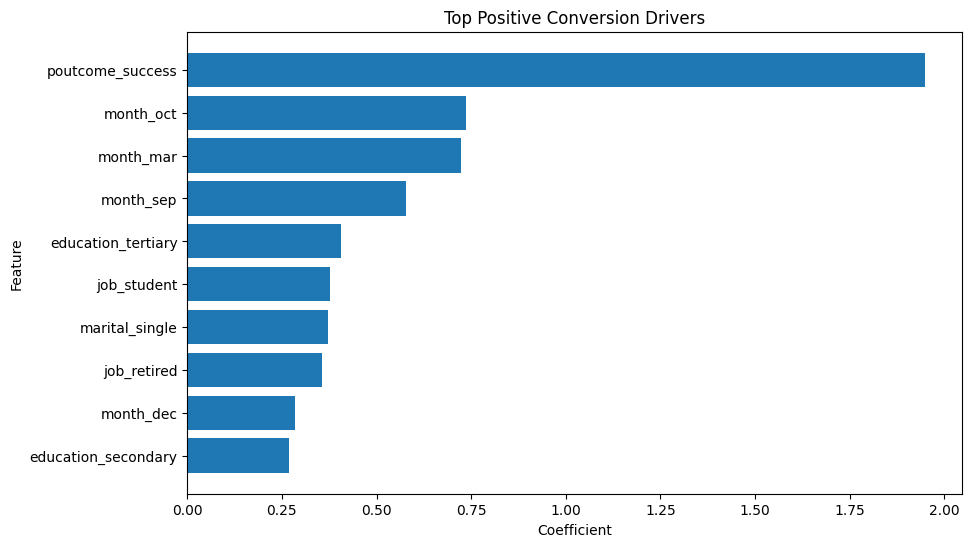

In [ ]:
import matplotlib.pyplot as plt

top_positive = coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Positive Conversion Drivers")

plt.gca().invert_yaxis()

plt.show()

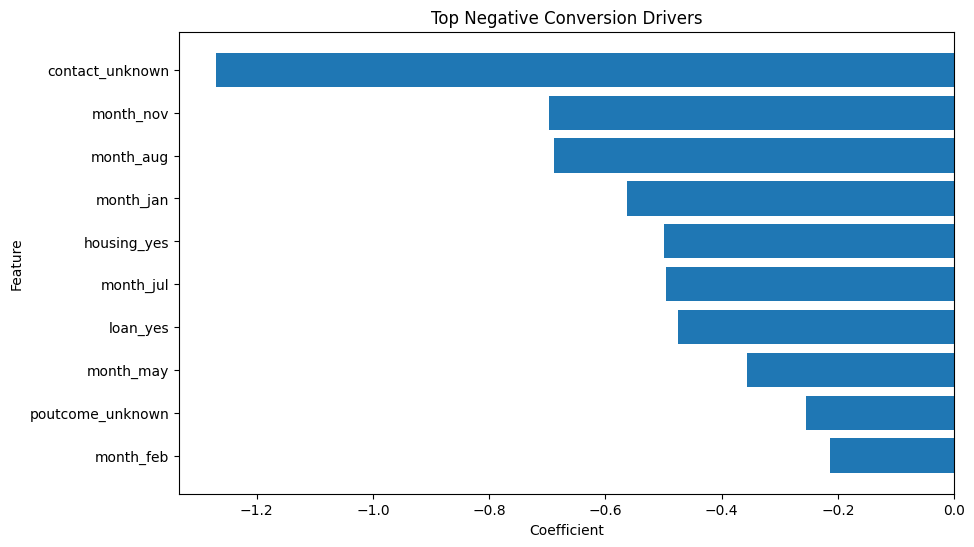

In [ ]:
top_negative = coefficients.sort_values(
    by="Coefficient"
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Negative Conversion Drivers")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_balanced
)

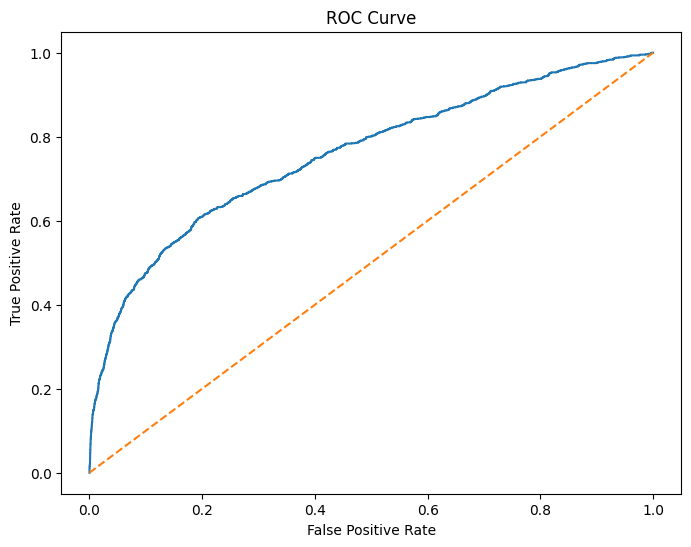

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8905230565077961

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nRandom Forest ROC AUC:")
print(roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
0.8925135463894726

Random Forest ROC AUC:
0.7786022966395993

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.67      0.22      0.33      1091

    accuracy                           0.89      9043
   macro avg       0.78      0.60      0.64      9043
weighted avg       0.87      0.89      0.87      9043



In [26]:
rf_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
1,balance,0.182949
0,age,0.155220
2,day,0.131577
3,campaign,0.063367
39,poutcome_success,0.057533
4,pdays,0.052710
5,previous,0.026155
23,housing_yes,0.021372
19,education_secondary,0.017454
14,job_technician,0.014487


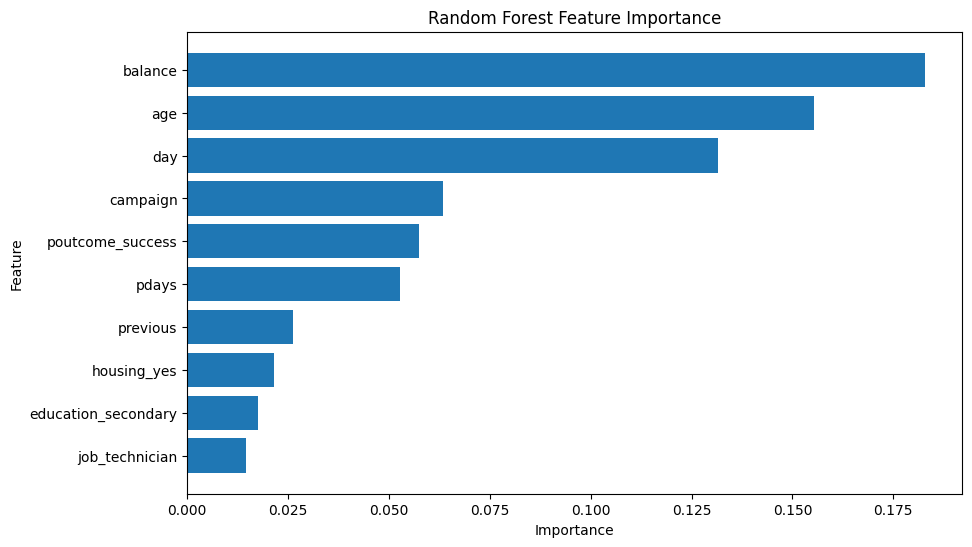

In [28]:
import matplotlib.pyplot as plt

top_rf = rf_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()